# Workshop: Generative AI with Diffusion Models
## Part 1: U-Nets and Forward Diffusion

Practical session (60 min)

This notebook is part of a workshop based on NVIDIA DLI materials
"Generative AI with Diffusion Models",
adapted for Google Colab with a T4 GPU.

Credits: Original course materials by NVIDIA Corporation / NVIDIA Deep Learning Institute.

### Learning Objectives

By the end of this notebook you will be able to:

- Load and visualize the FashionMNIST dataset prepared for diffusion
- Build a U-Net from scratch: DownBlock, UpBlock, and skip connections
- Train a simple image denoiser and understand its limitations
- Implement the forward diffusion process using a beta noise schedule
- Use the closed-form formula to jump directly to any noise level
- Run a first DDPM training with time-conditioned noise prediction

In [1]:
# All required packages are pre-installed on Colab
# torch, torchvision, matplotlib are already available

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if device.type == 'cuda':
    print('GPU   :', torch.cuda.get_device_name(0))

Device: cuda
GPU   : Tesla T4


---

## Part 1.1: The Dataset

We use [FashionMNIST](https://github.com/zalandoresearch/fashion-mnist):
70,000 grayscale images of clothing items in 10 categories.
We resize images to 16x16 pixels to keep training fast.

One important step: we rescale pixel values from [0, 1] to **[-1, 1]**.
This is required because the Gaussian noise we add is centered at 0,
so the image and the noise need to be in the same range.

100%|██████████| 26.4M/26.4M [00:00<00:00, 114MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.82MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 63.2MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.7MB/s]


Total images  : 70000
Batches/epoch : 546


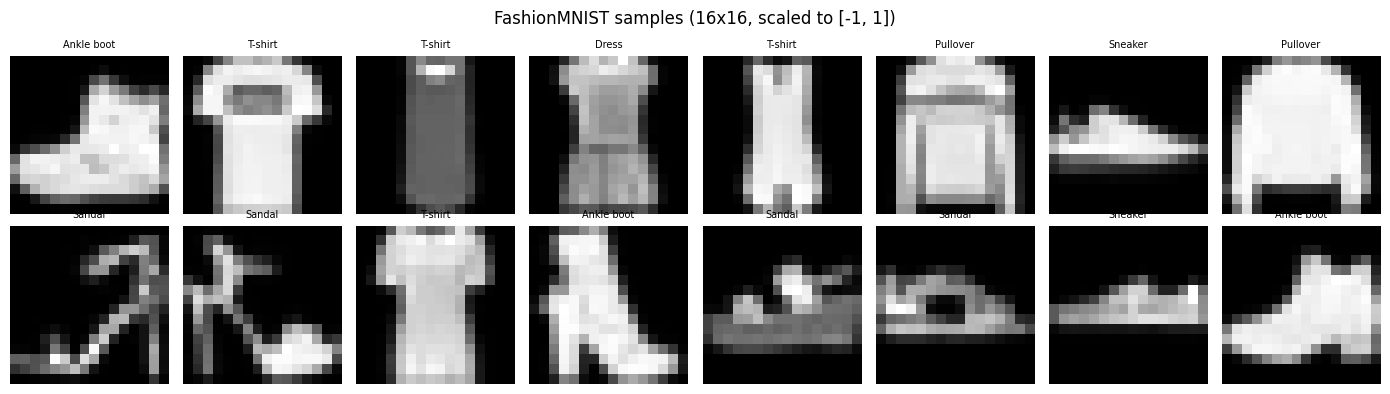

In [2]:
IMG_SIZE = 16    # resize to 16x16 (must be divisible by 4 for our U-Net)
IMG_CH = 1     # grayscale
BATCH_SIZE = 128

data_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),                                    # [0, 1]
    transforms.RandomHorizontalFlip(),
    transforms.Lambda(lambda t: (t * 2) - 1),               # [-1, 1]
])

train_set = torchvision.datasets.FashionMNIST('./data', download=True,  train=True,  transform=data_transforms)
test_set = torchvision.datasets.FashionMNIST('./data', download=True,  train=False, transform=data_transforms)
data = torch.utils.data.ConcatDataset([train_set, test_set])
dataloader = DataLoader(data, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

print(f'Total images  : {len(data)}')
print(f'Batches/epoch : {len(dataloader)}')

# Helper: convert a tensor in [-1, 1] to a displayable image
def show_tensor_image(image):
    to_img = transforms.Compose([
        transforms.Lambda(lambda t: (t + 1) / 2),       # back to [0, 1]
        transforms.Lambda(lambda t: t.clamp(0, 1)),
        transforms.ToPILImage(),
    ])
    plt.imshow(to_img(image[0].detach().cpu()), cmap='gray')

# Show a sample of images from the dataset
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    img, label = data[i]
    ax.imshow(((img + 1) / 2).squeeze().clamp(0, 1), cmap='gray')
    ax.set_title(class_names[label], fontsize=7)
    ax.axis('off')
plt.suptitle('FashionMNIST samples (16x16, scaled to [-1, 1])')
plt.tight_layout()
plt.show()

---

## Part 1.2: The U-Net Architecture

A U-Net has three parts:

- **Encoder (down path):** a series of DownBlocks that reduce spatial size
  and increase the number of channels. Each DownBlock extracts higher-level features.
- **Bottleneck:** the smallest representation, a flat vector, then reshaped back.
- **Decoder (up path):** a series of UpBlocks that increase spatial size back to the original.

The key idea is **skip connections**: the output of each DownBlock is copied
and concatenated to the input of the matching UpBlock.
This lets the decoder access fine spatial details that would otherwise be lost.

```
Input [1, 16, 16]
  down0 -> [16, 16, 16]  ---skip---> cat with up2
  down1 -> [32,  8,  8]  ---skip---> cat with up1
  down2 -> [64,  4,  4]  ---skip---> cat with up0
  bottleneck [1024]
  up0   -> [64,  4,  4]
  up1   -> [32,  8,  8]  (concat with down2 skip)
  up2   -> [16, 16, 16]  (concat with down1 skip)
  out   -> [ 1, 16, 16]  (concat with down0 skip)
```

In [3]:
class DownBlock(nn.Module):
    """Two convolutions followed by MaxPool to halve the spatial size."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

    def forward(self, x):
        return self.model(x)


class UpBlock(nn.Module):
    """Concatenate skip connection, then upsample with transposed convolution."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        # in_ch * 2 because we concatenate the skip connection before upsampling
        self.model = nn.Sequential(
            nn.ConvTranspose2d(2 * in_ch, out_ch, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
        )

    def forward(self, x, skip):
        x = torch.cat((x, skip), dim=1)   # concat along channel dimension
        return self.model(x)


print('DownBlock and UpBlock defined.')

DownBlock and UpBlock defined.


In [4]:
class UNet(nn.Module):
    def __init__(self, img_ch=IMG_CH, down_chs=(16, 32, 64)):
        super().__init__()
        up_chs = down_chs[::-1]              # (64, 32, 16)
        latent_size = IMG_SIZE // 4          # 16 // 4 = 4

        # Encoder
        self.down0 = nn.Sequential(          # initial conv, no pooling
            nn.Conv2d(img_ch, down_chs[0], 3, 1, 1),
            nn.BatchNorm2d(down_chs[0]),
            nn.ReLU(),
        )
        self.down1 = DownBlock(down_chs[0], down_chs[1])   # 16->32
        self.down2 = DownBlock(down_chs[1], down_chs[2])   # 32->64

        # Bottleneck
        self.to_vec   = nn.Sequential(nn.Flatten(), nn.ReLU())
        self.from_vec = nn.Sequential(
            nn.Linear(down_chs[2] * latent_size**2, down_chs[2] * latent_size**2),
            nn.ReLU(),
            nn.Unflatten(1, (up_chs[0], latent_size, latent_size)),
        )

        # Decoder
        self.up1 = UpBlock(up_chs[0], up_chs[1])   # 64->32
        self.up2 = UpBlock(up_chs[1], up_chs[2])   # 32->16

        # Output: concat up2 with down0 skip, then reduce to img_ch
        self.out = nn.Sequential(
            nn.Conv2d(2 * up_chs[-1], up_chs[-1], 3, 1, 1),
            nn.ReLU(),
            nn.Conv2d(up_chs[-1], img_ch, 3, 1, 1),
        )

    def forward(self, x):
        down0 = self.down0(x)          # [B, 16, 16, 16]
        down1 = self.down1(down0)      # [B, 32,  8,  8]
        down2 = self.down2(down1)      # [B, 64,  4,  4]

        latent = self.from_vec(self.to_vec(down2))   # [B, 64, 4, 4]

        up1 = self.up1(latent, down2)  # [B, 32, 8,  8]
        up2 = self.up2(up1,    down1)  # [B, 16, 16, 16]
        return self.out(torch.cat((up2, down0), dim=1))   # [B, 1, 16, 16]


# Quick sanity check
model = UNet().to(device)
test_input  = torch.randn(2, IMG_CH, IMG_SIZE, IMG_SIZE).to(device)
test_output = model(test_input)
print(f'Input  shape: {test_input.shape}')
print(f'Output shape: {test_output.shape}')
print(f'Parameters  : {sum(p.numel() for p in model.parameters()):,}')

Input  shape: torch.Size([2, 1, 16, 16])
Output shape: torch.Size([2, 1, 16, 16])
Parameters  : 1,182,145


---

## Part 1.3: Training a Simple Denoiser

Can we use this U-Net to remove noise from images?

The idea is simple:
1. Take a clean image
2. Add noise to it
3. Ask the model to predict the clean image back
4. Compute MSE between the prediction and the original

We use a fixed noise level `percent` that controls how much noise is added.
After training, we test the model at different noise levels
and then try generating images from pure noise.

This will show us exactly why a simple denoiser is not enough.

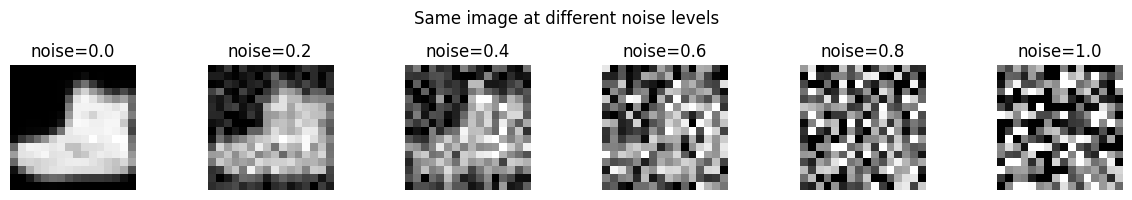

In [5]:
def add_noise(imgs, percent=0.5):
    """Add Gaussian noise to images. percent=0 is clean, percent=1 is pure noise."""
    noise = torch.randn_like(imgs)
    return (1 - percent) * imgs + percent * noise


def get_denoiser_loss(model, imgs):
    """Loss: predict clean image from noisy image."""
    noisy = add_noise(imgs, percent=0.5)
    pred  = model(noisy)
    return F.mse_loss(imgs, pred)


# Show what different noise levels look like
sample_img = data[0][0].unsqueeze(0).to(device)

fig, axes = plt.subplots(1, 6, figsize=(12, 2))
for i, pct in enumerate([0.0, 0.2, 0.4, 0.6, 0.8, 1.0]):
    noisy = add_noise(sample_img, percent=pct)
    axes[i].imshow(((noisy[0] + 1) / 2).clamp(0, 1).squeeze().cpu(), cmap='gray')
    axes[i].set_title(f'noise={pct:.1f}')
    axes[i].axis('off')
plt.suptitle('Same image at different noise levels')
plt.tight_layout()
plt.show()

In [6]:
# Train the simple denoiser
model = UNet().to(device)
optimizer = Adam(model.parameters(), lr=0.001)
EPOCHS = 2

model.train()
for epoch in range(EPOCHS):
    epoch_loss = 0
    for step, batch in enumerate(dataloader):
        optimizer.zero_grad()
        imgs = batch[0].to(device)
        loss = get_denoiser_loss(model, imgs)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f'Epoch {epoch+1}/{EPOCHS} | loss: {epoch_loss / len(dataloader):.5f}')

print('Training done.')

Epoch 1/2 | loss: 0.05812
Epoch 2/2 | loss: 0.04306
Training done.


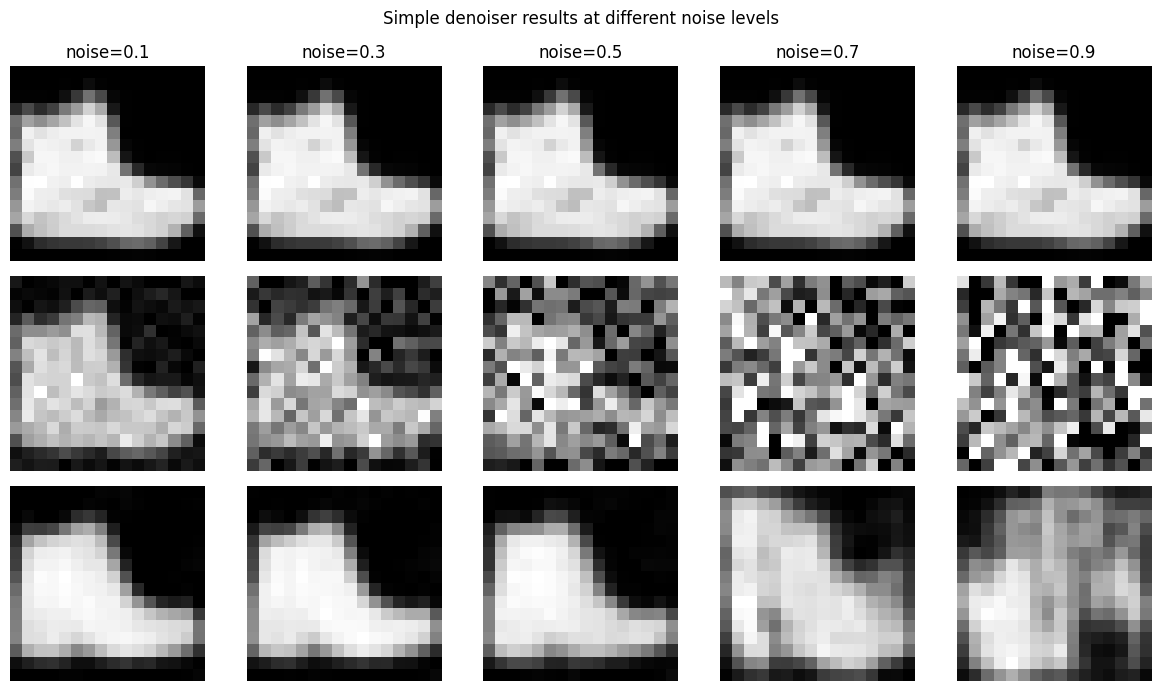

In [7]:
# Test the denoiser at different noise levels
model.eval()
sample_img = data[0][0].unsqueeze(0).to(device)

fig, axes = plt.subplots(3, 5, figsize=(12, 7))
noise_levels = [0.1, 0.3, 0.5, 0.7, 0.9]

for col, pct in enumerate(noise_levels):
    noisy = add_noise(sample_img, percent=pct)
    with torch.no_grad():
        pred = model(noisy)

    for row, (title, img) in enumerate([('Original', sample_img),
                                         ('Noisy input', noisy),
                                         ('Predicted', pred)]):
        axes[row, col].imshow(((img[0] + 1)/2).clamp(0,1).squeeze().cpu(), cmap='gray')
        if row == 0:
            axes[row, col].set_title(f'noise={pct:.1f}')
        if col == 0:
            axes[row, col].set_ylabel(title)
        axes[row, col].axis('off')

plt.suptitle('Simple denoiser results at different noise levels')
plt.tight_layout()
plt.show()

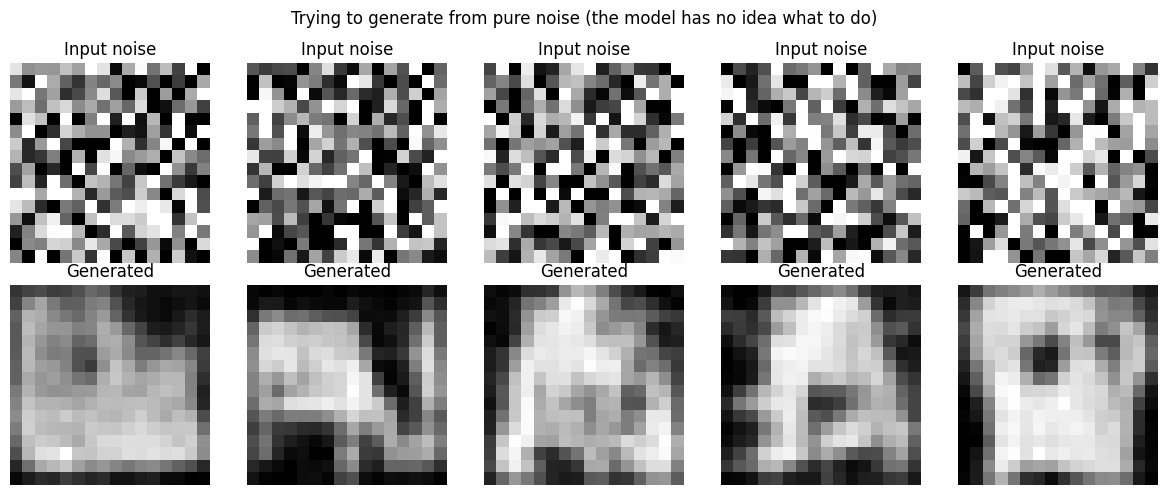

The model produces blurry blobs, not clothing.
Why? It was trained to remove a FIXED 50% noise level.
It has no idea what to do with 100% noise.
It also has no idea what TIMESTEP the noise comes from.


In [8]:
# Now try to GENERATE images: start from pure noise
model.eval()

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(5):
    noise = torch.randn(1, IMG_CH, IMG_SIZE, IMG_SIZE).to(device)
    with torch.no_grad():
        result = model(noise)
    axes[0, i].imshow(((noise[0]+1)/2).clamp(0,1).squeeze().cpu(), cmap='gray')
    axes[0, i].set_title('Input noise')
    axes[0, i].axis('off')
    axes[1, i].imshow(((result[0]+1)/2).clamp(0,1).squeeze().cpu(), cmap='gray')
    axes[1, i].set_title('Generated')
    axes[1, i].axis('off')

plt.suptitle('Trying to generate from pure noise (the model has no idea what to do)')
plt.tight_layout()
plt.show()

print('The model produces blurry blobs, not clothing.')
print('Why? It was trained to remove a FIXED 50% noise level.')
print('It has no idea what to do with 100% noise.')
print('It also has no idea what TIMESTEP the noise comes from.')

### What went wrong?

The simple denoiser has two problems:

1. **Fixed noise level:** it was trained with exactly 50% noise.
   Pure noise is a completely different distribution, so the model fails.

2. **No time information:** when generating images, we need to remove noise
   gradually over many steps. The model has no way to know which step it is at.

The solution is the **DDPM framework**:
- Define a noise schedule with T timesteps
- Train the model to predict the NOISE (not the clean image) at any timestep t
- Pass the timestep t as an input to the model
- At generation time, remove noise gradually from t=T down to t=0

---

## Part 1.4: Forward Diffusion

In DDPM, forward diffusion is a process that gradually adds noise to an image
over T timesteps. At each step t, a small amount of noise is added:

```
x_t = sqrt(1 - B_t) * x_{t-1} + sqrt(B_t) * noise
```

where `B_t` (beta) is a small number that grows with t.
After T steps, the image becomes pure Gaussian noise.

The **beta schedule** controls how fast noise is added:
- t=0: almost no noise
- t=T: pure noise

A key result from DDPM: we can skip directly to any timestep t without
running the recursion step by step. This is the **closed-form** formula:

```
x_t = sqrt(a_bar_t) * x_0 + sqrt(1 - a_bar_t) * noise
```

where `a_bar_t` is the cumulative product of all `(1 - B)` values up to step t.
When `a_bar_t` is close to 1, the image is mostly clean.
When `a_bar_t` is close to 0, the image is mostly noise.

In [12]:
T = 300  # total number of diffusion timesteps

# Beta schedule: linearly increasing from 0.0001 to 0.02
# This matches the original DDPM paper
B      = torch.linspace(0.0001, 0.02, T).to(device)

# Derived quantities
a      = 1.0 - B
a_bar  = torch.cumprod(a, dim=0)         # cumulative product
sqrt_a_bar           = torch.sqrt(a_bar)
sqrt_one_minus_a_bar = torch.sqrt(1 - a_bar)

# Variables used in reverse diffusion (Part 2)
sqrt_a_inv       = torch.sqrt(1 / a)
pred_noise_coeff = (1 - a) / sqrt_one_minus_a_bar

print(f'B: min = {B.min():.5f}, max={B.max():.5f}')
print(f'a_bar: first = {a_bar[0]:.4f} (clean), last = {a_bar[-1]:.6f} (noisy)')

B: min = 0.00010, max=0.02000
a_bar: first = 0.9999 (clean), last = 0.048058 (noisy)


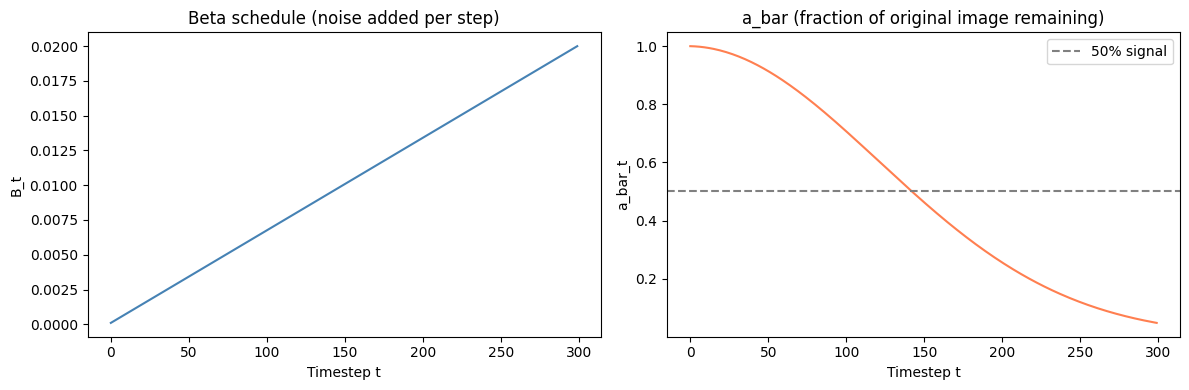

The image is 50% noise at timestep t=143 out of T=300


In [13]:
# Visualize how the noise schedule behaves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

t_vals = range(T)
axes[0].plot(B.cpu(), color='steelblue')
axes[0].set_title('Beta schedule (noise added per step)')
axes[0].set_xlabel('Timestep t')
axes[0].set_ylabel('B_t')

axes[1].plot(a_bar.cpu(), color='coral')
axes[1].set_title('a_bar (fraction of original image remaining)')
axes[1].set_xlabel('Timestep t')
axes[1].set_ylabel('a_bar_t')
axes[1].axhline(0.5, color='gray', linestyle='--', label='50% signal')
axes[1].legend()

plt.tight_layout()
plt.show()

# Find where a_bar crosses 0.5
halfway = (a_bar < 0.5).nonzero()[0].item()
print(f'The image is 50% noise at timestep t={halfway} out of T={T}')

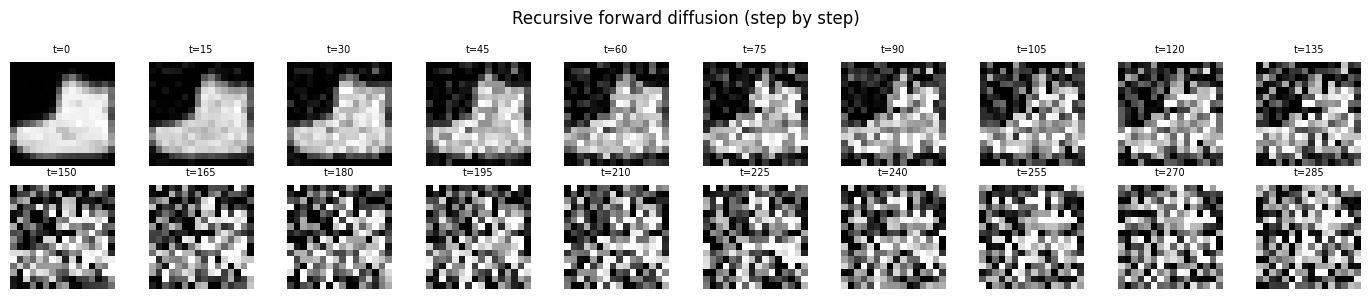

In [14]:
# Recursive forward diffusion: add noise one step at a time
# This is the original approach - slow but easy to understand

x_0 = data[0][0].to(device)   # one image from the dataset
x_t = x_0.clone()
xs_recursive = []

for t in range(T):
    noise = torch.randn_like(x_t)
    x_t = torch.sqrt(1 - B[t]) * x_t + torch.sqrt(B[t]) * noise
    xs_recursive.append(x_t.detach().cpu())

# Show 20 evenly spaced timesteps
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
step = T // 20
for i, ax in enumerate(axes.flat):
    t_idx = i * step
    ax.imshow(((xs_recursive[t_idx] + 1)/2).clamp(0,1).squeeze(), cmap='gray')
    ax.set_title(f't={t_idx}', fontsize=7)
    ax.axis('off')
plt.suptitle('Recursive forward diffusion (step by step)')
plt.tight_layout()
plt.show()

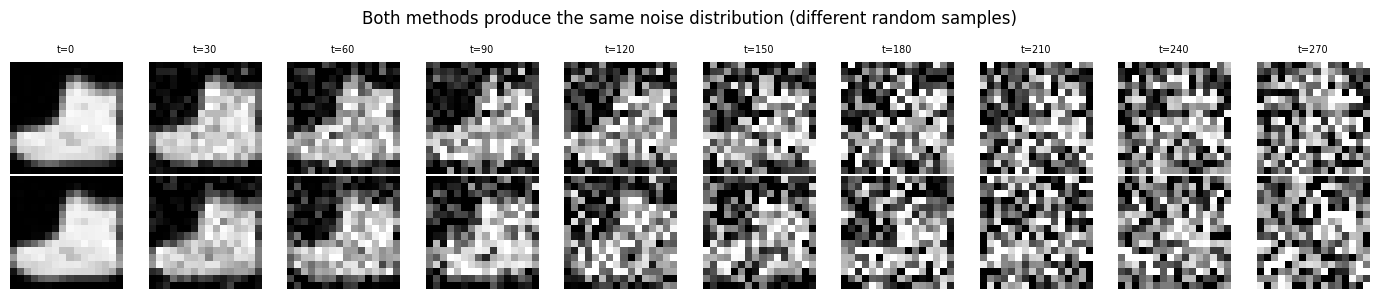

In [15]:
# Closed-form forward diffusion: jump directly to any timestep
# Much faster for training: no need to iterate through all previous steps

def q(x_0, t):
    """
    Closed-form forward diffusion.
    Given a clean image x_0 and a timestep t, returns the noisy image x_t
    and the noise that was added.
    """
    t = t.int()
    noise           = torch.randn_like(x_0)
    sqrt_a_bar_t    = sqrt_a_bar[t, None, None, None]
    sqrt_1m_a_bar_t = sqrt_one_minus_a_bar[t, None, None, None]
    x_t = sqrt_a_bar_t * x_0 + sqrt_1m_a_bar_t * noise
    return x_t, noise


# Compare recursive and closed-form for the same image
x_0_batch = data[0][0].unsqueeze(0).to(device)  # add batch dimension

fig, axes = plt.subplots(2, 10, figsize=(14, 3))
step = T // 10
for i in range(10):
    t_idx = i * step
    t_tensor = torch.tensor([t_idx]).to(device)
    x_t_cf, _ = q(x_0_batch, t_tensor)

    # Recursive result
    axes[0, i].imshow(((xs_recursive[t_idx]+1)/2).clamp(0,1).squeeze(), cmap='gray')
    axes[0, i].set_title(f't={t_idx}', fontsize=7)
    axes[0, i].axis('off')

    # Closed-form result
    axes[1, i].imshow(((x_t_cf[0]+1)/2).clamp(0,1).squeeze().cpu(), cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Recursive', fontsize=8)
axes[1, 0].set_ylabel('Closed-form', fontsize=8)
plt.suptitle('Both methods produce the same noise distribution (different random samples)')
plt.tight_layout()
plt.show()

---

## Part 1.5: DDPM Training with Time Conditioning

Now we fix the two problems of the simple denoiser:

1. **Variable noise level:** we sample a random timestep t for each image
   and use `q(x_0, t)` to add exactly the right amount of noise.

2. **Time information:** we add a time embedding block to the U-Net.
   The model receives t as an additional input and adjusts its predictions.

**The training objective also changes:** instead of predicting the clean image,
the model now predicts the NOISE that was added.
This is a key insight from the DDPM paper: predicting noise is easier
than predicting the clean image, especially at high noise levels.

```
loss = MSE(actual_noise, model(noisy_image, t))
```

In [16]:
import gc

# Free memory from the previous model before loading the new one
del model
gc.collect()
torch.cuda.empty_cache()

# ---- Time Embedding Block ----
# Takes a scalar timestep t and produces a [B, emb_dim, 1, 1] tensor
# that can be broadcast-multiplied with any feature map
class EmbedBlock(nn.Module):
    def __init__(self, input_dim, emb_dim):
        super().__init__()
        self.input_dim = input_dim
        self.model = nn.Sequential(
            nn.Linear(input_dim, emb_dim),
            nn.ReLU(),
            nn.Linear(emb_dim, emb_dim),
            nn.Unflatten(1, (emb_dim, 1, 1)),
        )

    def forward(self, x):
        return self.model(x.view(-1, self.input_dim))


# ---- Time-conditioned U-Net ----
class UNetTimed(nn.Module):
    def __init__(self, T, img_ch=IMG_CH, down_chs=(16, 32, 64)):
        super().__init__()
        self.T = T
        up_chs      = down_chs[::-1]
        latent_size = IMG_SIZE // 4
        t_dim       = 1           # input dimension for time (normalized scalar)

        # Encoder
        self.down0 = nn.Sequential(
            nn.Conv2d(img_ch, down_chs[0], 3, 1, 1),
            nn.BatchNorm2d(down_chs[0]),
            nn.ReLU(),
        )
        self.down1 = DownBlock(down_chs[0], down_chs[1])
        self.down2 = DownBlock(down_chs[1], down_chs[2])

        # Bottleneck
        self.to_vec   = nn.Sequential(nn.Flatten(), nn.ReLU())
        self.from_vec = nn.Sequential(
            nn.Linear(down_chs[2] * latent_size**2, down_chs[2] * latent_size**2),
            nn.ReLU(),
            nn.Unflatten(1, (up_chs[0], latent_size, latent_size)),
        )

        # Time embeddings (one for each UpBlock)
        self.t_emb1 = EmbedBlock(t_dim, up_chs[0])   # [B, 64, 1, 1]
        self.t_emb2 = EmbedBlock(t_dim, up_chs[1])   # [B, 32, 1, 1]

        # Decoder
        self.up1 = UpBlock(up_chs[0], up_chs[1])
        self.up2 = UpBlock(up_chs[1], up_chs[2])

        # Output
        self.out = nn.Sequential(
            nn.Conv2d(2 * up_chs[-1], up_chs[-1], 3, 1, 1),
            nn.ReLU(),
            nn.Conv2d(up_chs[-1], img_ch, 3, 1, 1),
        )

    def forward(self, x, t):
        # Normalize t from [0, T] to [0, 1]
        t_norm = (t.float() / self.T).view(-1, 1)

        down0  = self.down0(x)
        down1  = self.down1(down0)
        down2  = self.down2(down1)
        latent = self.from_vec(self.to_vec(down2))

        # Multiply time embedding into the up-path feature maps
        # Broadcasting: [B, ch, 1, 1] * [B, ch, h, w] -> [B, ch, h, w]
        t1 = self.t_emb1(t_norm)     # [B, 64, 1, 1]
        t2 = self.t_emb2(t_norm)     # [B, 32, 1, 1]

        up1 = self.up1(t1 * latent, down2)
        up2 = self.up2(t2 * up1,    down1)
        return self.out(torch.cat((up2, down0), dim=1))


model = UNetTimed(T).to(device)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

# Verify shapes
x_test = torch.randn(2, IMG_CH, IMG_SIZE, IMG_SIZE).to(device)
t_test = torch.tensor([50., 150.]).to(device)
print(f'Output shape: {model(x_test, t_test).shape}')

Parameters: 1,187,553
Output shape: torch.Size([2, 1, 16, 16])


In [17]:
# DDPM training loop
# For each batch:
#   1. Sample a random timestep t for each image
#   2. Add the right amount of noise using q(x_0, t)
#   3. Ask the model to predict the noise
#   4. Compute MSE between predicted and actual noise

optimizer = Adam(model.parameters(), lr=0.001)
EPOCHS = 2

model.train()
for epoch in range(EPOCHS):
    epoch_loss = 0
    for step, batch in enumerate(dataloader):
        optimizer.zero_grad()
        x_0 = batch[0].to(device)

        # Sample a random timestep for each image in the batch
        t = torch.randint(0, T, (BATCH_SIZE,), device=device).float()

        # Add noise using the closed-form formula
        x_noisy, noise = q(x_0, t)

        # The model predicts the noise, not the clean image
        noise_pred = model(x_noisy, t)

        loss = F.mse_loss(noise, noise_pred)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    print(f'Epoch {epoch+1}/{EPOCHS} | loss: {epoch_loss / len(dataloader):.5f}')

print('Training done.')

Epoch 1/2 | loss: 0.15689
Epoch 2/2 | loss: 0.10324
Training done.


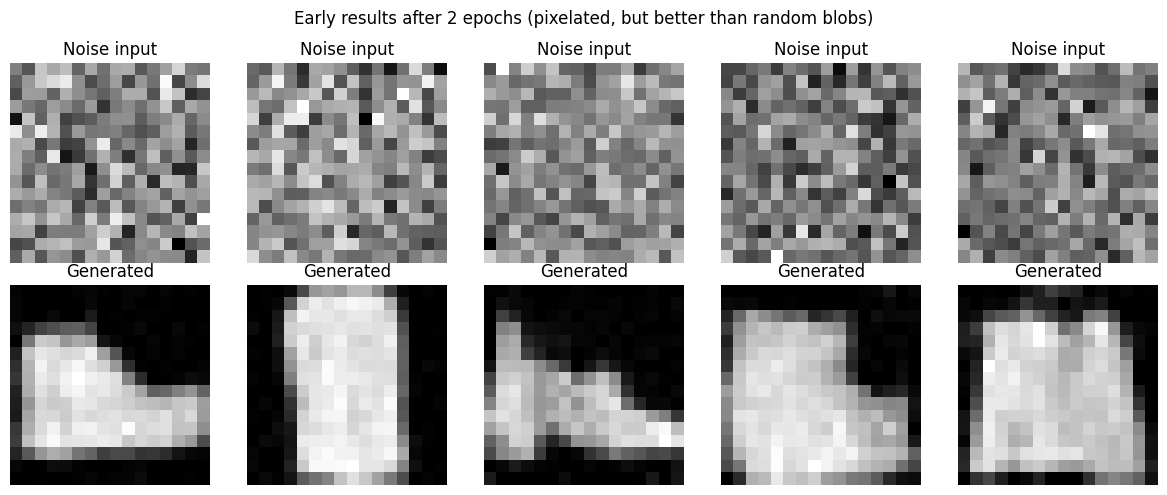

The results look pixelated. This is expected after only 2 epochs.
In Part 2, we will improve the architecture and train for longer.


In [18]:
# Quick look at what the model has learned after 2 epochs
# Full reverse diffusion will be covered in Part 2
# Here we just do a simplified version to get an early look

model.eval()

@torch.no_grad()
def simple_sample(model, n_steps=T):
    """Very basic reverse diffusion: remove noise step by step."""
    x_t = torch.randn(1, IMG_CH, IMG_SIZE, IMG_SIZE, device=device)
    for i in range(n_steps - 1, -1, -1):
        t = torch.tensor([i], device=device).float()
        e_t = model(x_t, t)   # predicted noise

        # Simplified reverse step (exact derivation in Part 2)
        x_t = sqrt_a_inv[i] * (x_t - pred_noise_coeff[i] * e_t)
        if i > 0:
            x_t = x_t + torch.sqrt(B[i-1]) * torch.randn_like(x_t)
    return x_t


fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(5):
    result = simple_sample(model)
    axes[0, i].imshow(torch.randn(IMG_SIZE, IMG_SIZE).cpu(), cmap='gray')
    axes[0, i].set_title('Noise input')
    axes[0, i].axis('off')
    axes[1, i].imshow(((result[0]+1)/2).clamp(0,1).squeeze().cpu(), cmap='gray')
    axes[1, i].set_title('Generated')
    axes[1, i].axis('off')

plt.suptitle('Early results after 2 epochs (pixelated, but better than random blobs)')
plt.tight_layout()
plt.show()

print('The results look pixelated. This is expected after only 2 epochs.')
print('In Part 2, we will improve the architecture and train for longer.')

---

## Wrapping Up

In this notebook you have:

- Loaded FashionMNIST scaled to [-1, 1] for diffusion training
- Built a U-Net from scratch with DownBlocks, UpBlocks, and skip connections
- Trained a simple denoiser and seen why it fails at generation
- Implemented the beta noise schedule and visualized how noise accumulates
- Used the closed-form formula to jump directly to any noise level
- Trained a time-conditioned U-Net with the DDPM noise prediction objective

**Key points:**

- Skip connections preserve spatial detail across the encoder-decoder bottleneck
- The DDPM framework trains the model to predict noise, not clean images
- The closed-form `q(x_0, t)` lets us sample any noise level in one step during training
- After only 2 epochs, results are pixelated

**Part 2** covers the reverse diffusion process in detail
and adds architectural improvements that fix the pixelation.

In [19]:
# Run this cell before opening the Part 2 notebook
import IPython
app = IPython.Application.instance()
app.kernel.do_shutdown(True)

{'status': 'ok', 'restart': True}